In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# 1. Generate random dataset
np.random.seed(42)

n = 4000

df = pd.DataFrame({
    "Var1": np.random.rand(n),
    "Var2": np.random.rand(n),
    "Var3": np.random.rand(n),
    "Var4": np.random.rand(n),
    "Var5": np.random.rand(n),
    "Var6": np.random.rand(n),
    "Target": np.random.randint(0, 2, n)
})

print(df.head())

       Var1      Var2      Var3      Var4      Var5      Var6  Target
0  0.374540  0.571996  0.720268  0.654306  0.004402  0.729998       1
1  0.950714  0.805432  0.687283  0.080033  0.000330  0.184512       1
2  0.731994  0.760161  0.095754  0.242330  0.472263  0.346640       1
3  0.598658  0.153900  0.922572  0.773679  0.029294  0.663281       1
4  0.156019  0.149249  0.568472  0.528686  0.974533  0.482089       1


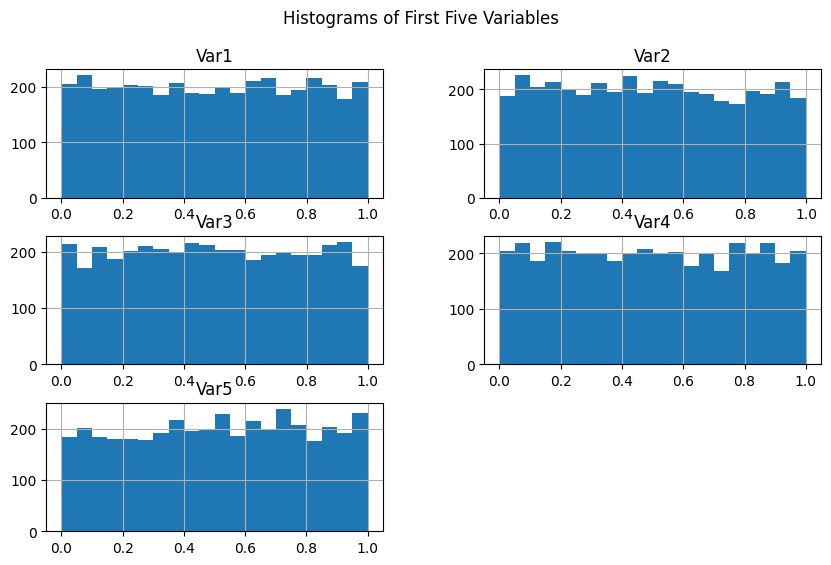

In [3]:
# 2. Plot histograms for first five variables
df[["Var1", "Var2", "Var3", "Var4", "Var5"]].hist(
    figsize=(10, 6),
    bins=20
)

plt.suptitle("Histograms of First Five Variables")
plt.show()

In [4]:
# 3. Separate features and target
X = df.drop("Target", axis=1)
y = df["Target"]

In [6]:
# 4. Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [7]:
# 5. Train Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [8]:
# 6. Predict test set
y_pred = rf.predict(X_test)

In [9]:
# 7. Evaluate model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[319 282]
 [296 303]]

Accuracy:
0.5183333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.53      0.52       601
           1       0.52      0.51      0.51       599

    accuracy                           0.52      1200
   macro avg       0.52      0.52      0.52      1200
weighted avg       0.52      0.52      0.52      1200



## Reflection

The accuracy is low because both the input variables and target values are randomly generated. There is no real relationship between Var1–Var6 and Target.

### To improve accuracy, we need:

real data with meaningful patterns,
better feature engineering,
relevant variables related to the target,
hyperparameter tuning,
or a target variable created from the features rather than randomly generated.